# Эксперимент 1 — Регрессионные модели

Данные: `merged_clean.csv` (без макроданных и внешних признаков)

Train: 2018–2020 (~1.5M, стратифицированная выборка по годам)

Test: 2021 (~500k, случайная выборка)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Загрузка и разделение данных

In [2]:
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['date'])
print('Загружено:', df.shape)

# Извлекаем год и месяц как признаки
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Разделение по времени
train_full = df[df['year'] <= 2020].copy()
test_full  = df[df['year'] == 2021].copy()

print(f'Train (2018–2020): {len(train_full):,}')
print(f'Test  (2021):      {len(test_full):,}')
print()
print('Записей по годам (train):')
print(train_full['year'].value_counts().sort_index())

Загружено: (16815835, 13)
Train (2018–2020): 4,902,771
Test  (2021):      11,913,064

Записей по годам (train):
year
2018     871151
2019    2231544
2020    1800076
Name: count, dtype: int64


In [3]:
# Стратифицированная выборка train по годам (~1.5M)
TRAIN_SAMPLE = 1_500_000
year_counts = train_full['year'].value_counts()
year_fracs  = year_counts / year_counts.sum()

train_parts = []
for year, frac in year_fracs.items():
    n = int(TRAIN_SAMPLE * frac)
    part = train_full[train_full['year'] == year].sample(n, random_state=RANDOM_STATE)
    train_parts.append(part)
    print(f'  {year}: {n:,} записей')

train = pd.concat(train_parts, ignore_index=True)
test  = test_full.sample(500_000, random_state=RANDOM_STATE)

print(f'\nИтого train: {len(train):,}')
print(f'Итого test:  {len(test):,}')

  2019: 682,739 записей
  2020: 550,732 записей
  2018: 266,528 записей

Итого train: 1,499,999
Итого test:  500,000


## 2. Подготовка признаков

In [4]:
FEATURES = ['area', 'kitchen_area', 'level', 'levels', 'rooms',
            'object_type', 'region', 'dist_to_center',
            'geo_lat', 'geo_lon', 'year', 'month']
TARGET = 'price'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print()
print('Пропуски в train:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

X_train: (1499999, 12)
X_test:  (500000, 12)

Пропуски в train:
Series([], dtype: int64)


## 3. Функция оценки моделей

In [5]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = root_mean_squared_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f'{name:30s}  MAE={mae/1e6:.3f}M  RMSE={rmse/1e6:.3f}M  R²={r2:.4f}')
    return model

## 4. Линейные модели

In [6]:
# Для линейных моделей заполняем NaN медианой
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

evaluate('Linear Regression',  LinearRegression(),       X_train_imp, y_train, X_test_imp, y_test)
evaluate('Ridge',              Ridge(alpha=1.0),          X_train_imp, y_train, X_test_imp, y_test)
evaluate('Lasso',              Lasso(alpha=100.0),        X_train_imp, y_train, X_test_imp, y_test)

Linear Regression               MAE=3.278M  RMSE=12.094M  R²=0.1505
Ridge                           MAE=3.278M  RMSE=12.094M  R²=0.1505
Lasso                           MAE=3.278M  RMSE=12.094M  R²=0.1505


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",100.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


## 5. Random Forest

In [7]:
rf = evaluate('Random Forest',
    RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_imp, y_train, X_test_imp, y_test
)

Random Forest                   MAE=1.854M  RMSE=6.908M  R²=0.7228


## 6. XGBoost

In [8]:
xgb = evaluate('XGBoost',
    XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                 subsample=0.8, colsample_bytree=0.8,
                 n_jobs=-1, random_state=RANDOM_STATE),
    X_train_imp, y_train, X_test_imp, y_test
)

XGBoost                         MAE=1.814M  RMSE=7.697M  R²=0.6559


## 7. LightGBM

In [9]:
lgbm = evaluate('LightGBM',
    LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                  num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                  n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
    X_train, y_train, X_test, y_test
)

LightGBM                        MAE=1.825M  RMSE=7.222M  R²=0.6971


## 8. CatBoost

In [10]:
cb = evaluate('CatBoost',
    CatBoostRegressor(iterations=500, learning_rate=0.05, depth=7,
                      random_seed=RANDOM_STATE, verbose=0),
    X_train, y_train, X_test, y_test
)

CatBoost                        MAE=1.913M  RMSE=7.660M  R²=0.6591


## 9. Сравнение моделей

,"MAE, млн","RMSE, млн",R²
Random Forest,1.854,6.908,0.7228
LightGBM,1.825,7.222,0.6971
CatBoost,1.913,7.660,0.6591
XGBoost,1.814,7.697,0.6559
Linear Regression,3.278,12.094,0.1505
Ridge,3.278,12.094,0.1505
Lasso,3.278,12.094,0.1505


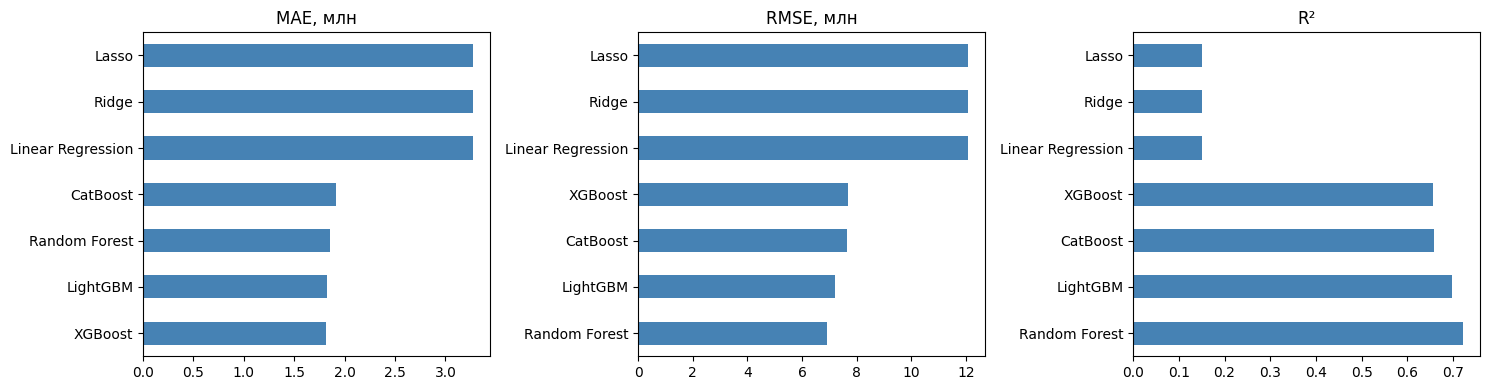

In [11]:
results_df = pd.DataFrame(results).T
results_df['MAE, млн'] = (results_df['MAE'] / 1e6).round(3)
results_df['RMSE, млн'] = (results_df['RMSE'] / 1e6).round(3)
results_df['R²'] = results_df['R²'].round(4)
display(results_df[['MAE, млн', 'RMSE, млн', 'R²']].sort_values('R²', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE, млн', 'RMSE, млн', 'R²']):
    ascending = metric != 'R²'
    results_df[metric].sort_values(ascending=ascending).plot(
        kind='barh', ax=ax, color='steelblue')
    ax.set_title(metric)
plt.tight_layout()
plt.show()

## 10. SHAP — важность признаков (LightGBM)

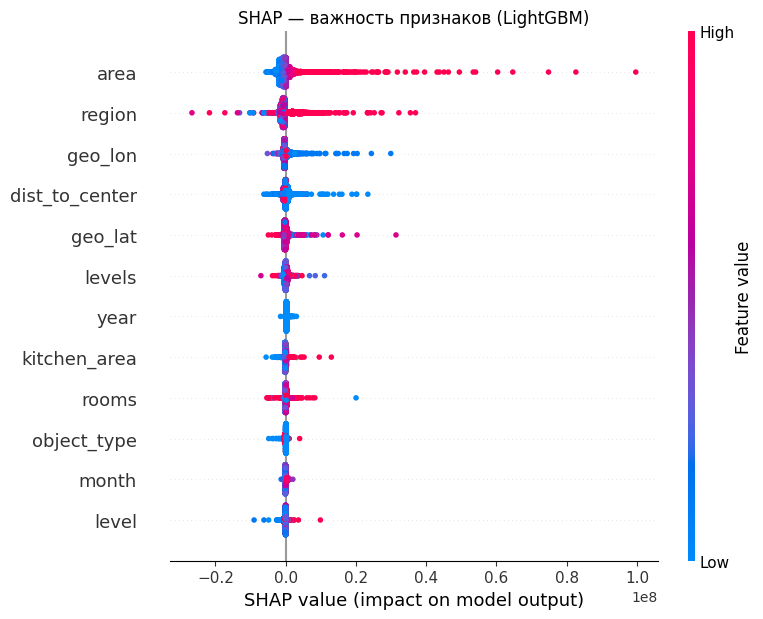

In [12]:
shap_sample = X_test.sample(5000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES, show=False)
plt.title('SHAP — важность признаков (LightGBM)')
plt.tight_layout()
plt.show()